# 1. Data Loading and Initial Inspection

The dataset is loaded and inspected to understand its structure, data types, and missing values. 
A copy of the selected columns is created so the original raw dataset remains unchanged.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
# Load the raw dataset
raw_df = pd.read_csv("data/raw/FullData.csv")

# Keep only required columns
df = raw_df[
    [
        "Name",
        "Nationality",
        "National_Position",
        "Club",
        "Club_Position",
        "Rating",
        "Height",
        "Weight",
        "Birth_Date",
        "Age",
        "Skill_Moves",
        "Ball_Control",
        "Dribbling",
        "Speed",
        "Strength"
    ]
].copy()

# Preview
df.head()

,Name,Nationality,National_Position,Club,Club_Position,Rating,Height,Weight,Birth_Date,Age,Skill_Moves,Ball_Control,Dribbling,Speed,Strength
0,Cristiano Ronaldo,Portugal,LS,Real Madrid,LW,94,185 cm,80 kg,02/05/1985,32,5,93,92,92,80
1,Lionel Messi,Argentina,RW,FC Barcelona,RW,93,170 cm,72 kg,06/24/1987,29,4,95,97,87,59
2,Neymar,Brazil,LW,FC Barcelona,LW,92,174 cm,68 kg,02/05/1992,25,5,95,96,90,49
3,Luis Suárez,Uruguay,LS,FC Barcelona,ST,92,182 cm,85 kg,01/24/1987,30,4,91,86,77,76
4,Manuel Neuer,Germany,GK,FC Bayern,GK,92,193 cm,92 kg,03/27/1986,31,1,48,30,61,83


In [99]:
# Check the shape of the dataset
df.shape

(17588, 15)

In [100]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17588 entries, 0 to 17587
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Name               17588 non-null  str  
 1   Nationality        17588 non-null  str  
 2   National_Position  1075 non-null   str  
 3   Club               17588 non-null  str  
 4   Club_Position      17587 non-null  str  
 5   Rating             17588 non-null  int64
 6   Height             17588 non-null  str  
 7   Weight             17588 non-null  str  
 8   Birth_Date         17588 non-null  str  
 9   Age                17588 non-null  int64
 10  Skill_Moves        17588 non-null  int64
 11  Ball_Control       17588 non-null  int64
 12  Dribbling          17588 non-null  int64
 13  Speed              17588 non-null  int64
 14  Strength           17588 non-null  int64
dtypes: int64(7), str(8)
memory usage: 2.0 MB


In [101]:
# Statistical summary of numerical columns
df.describe()

,Rating,Age,Skill_Moves,Ball_Control,Dribbling,Speed,Strength
count,17588.000000,17588.000000,17588.000000,17588.000000,17588.000000,17588.000000,17588.000000
mean,66.166193,25.460314,2.303161,57.972766,54.802877,65.483853,65.085854
std,7.083012,4.680217,0.746156,16.834779,18.913857,14.100615,12.532989
min,45.000000,17.000000,1.000000,5.000000,4.000000,11.000000,20.000000
25%,62.000000,22.000000,2.000000,53.000000,47.000000,58.000000,57.000000
50%,66.000000,25.000000,2.000000,63.000000,60.000000,68.000000,66.000000
75%,71.000000,29.000000,3.000000,69.000000,68.000000,75.000000,74.000000
max,94.000000,47.000000,5.000000,95.000000,97.000000,96.000000,98.000000


In [102]:
# Check for missing values
df.isnull().sum()

Name                     0
Nationality              0
National_Position    16513
Club                     0
Club_Position            1
Rating                   0
Height                   0
Weight                   0
Birth_Date               0
Age                      0
Skill_Moves              0
Ball_Control             0
Dribbling                0
Speed                    0
Strength                 0
dtype: int64

In [103]:
# Series example
example_series = pd.Series([1, 2, 3])
example_series

0    1
1    2
2    3
dtype: int64

In [104]:
# DataFrame example
example_df = pd.DataFrame({
    "A": [1, 2],
    "B": [3, 4]
})
example_df

,A,B
0,1,3
1,2,4


In [105]:
# iloc example
df.iloc[0:5, 0:5]

,Name,Nationality,National_Position,Club,Club_Position
0,Cristiano Ronaldo,Portugal,LS,Real Madrid,LW
1,Lionel Messi,Argentina,RW,FC Barcelona,RW
2,Neymar,Brazil,LW,FC Barcelona,LW
3,Luis Suárez,Uruguay,LS,FC Barcelona,ST
4,Manuel Neuer,Germany,GK,FC Bayern,GK


In [106]:
# loc example
df.loc[df['Rating'] > 85, ['Name', 'Club', 'Rating']].head()

,Name,Club,Rating
0,Cristiano Ronaldo,Real Madrid,94
1,Lionel Messi,FC Barcelona,93
2,Neymar,FC Barcelona,92
3,Luis Suárez,FC Barcelona,92
4,Manuel Neuer,FC Bayern,92


In [107]:
# boolean filtering
df[df["Rating"] >= 85].head()

,Name,Nationality,National_Position,Club,Club_Position,Rating,Height,Weight,Birth_Date,Age,Skill_Moves,Ball_Control,Dribbling,Speed,Strength
0,Cristiano Ronaldo,Portugal,LS,Real Madrid,LW,94,185 cm,80 kg,02/05/1985,32,5,93,92,92,80
1,Lionel Messi,Argentina,RW,FC Barcelona,RW,93,170 cm,72 kg,06/24/1987,29,4,95,97,87,59
2,Neymar,Brazil,LW,FC Barcelona,LW,92,174 cm,68 kg,02/05/1992,25,5,95,96,90,49
3,Luis Suárez,Uruguay,LS,FC Barcelona,ST,92,182 cm,85 kg,01/24/1987,30,4,91,86,77,76
4,Manuel Neuer,Germany,GK,FC Bayern,GK,92,193 cm,92 kg,03/27/1986,31,1,48,30,61,83


# 2. Cleaning and Transformation
The dataset is cleaned by removing duplicate records, handling missing values, converting data types, and transforming height and weight into more interpretable units. A new feature is also created to categorize player performance levels.

Duplicate names are not removed by name alone because the same player name may appear across different clubs. Instead, duplicates will be checked and removed using both Name and Club.

In [108]:
# Check true duplicates using Name + Club
df.duplicated(subset=["Name", "Club"]).sum()

np.int64(4)

In [109]:
# Remove true duplicate player-club records
df = df.drop_duplicates(subset=["Name", "Club"])

In [110]:
# Confirm duplicates were removed
df.duplicated(subset=["Name", "Club"]).sum()

np.int64(0)

In [111]:
# Fill missing national positions with "Unknown"
# These are not removed because many players do not have a national team position
df["National_Position"] = df["National_Position"].fillna("Unknown")

In [112]:
# Remove rows with missing club positions
df = df.dropna(subset=["Club_Position"])

In [113]:
# Convert birth date to datetime
df["Birth_Date"] = pd.to_datetime(df["Birth_Date"], errors="coerce")

In [114]:
# Convert selected columns to numeric
numeric_cols = [
    "Rating",
    "Age",
    "Skill_Moves",
    "Ball_Control",
    "Dribbling",
    "Speed",
    "Strength"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Height and weight were originally recorded in centimeters and kilograms. They were converted to inches and pounds to make the data more interpretable.

In [115]:
# Clean Height: convert from strings like "185 cm" to inches
df["Height"] = df["Height"].astype(str).str.replace(" cm", "", regex=False).str.strip()
df["Height"] = pd.to_numeric(df["Height"], errors="coerce")
df["Height"] = (df["Height"] / 2.54).round(2)

In [116]:
# Clean Weight: convert from strings like "80 kg" to pounds
df["Weight"] = df["Weight"].astype(str).str.replace(" kg", "", regex=False).str.strip()
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")
df["Weight"] = (df["Weight"] * 2.20462).round(2)

In [117]:
df[["Height", "Weight"]].head()

,Height,Weight
0,72.83,176.37
1,66.93,158.73
2,68.50,149.91
3,71.65,187.39
4,75.98,202.83


In [118]:
# Check missing values again after conversions
df.isnull().sum()

Name                 0
Nationality          0
National_Position    0
Club                 0
Club_Position        0
Rating               0
Height               0
Weight               0
Birth_Date           0
Age                  0
Skill_Moves          0
Ball_Control         0
Dribbling            0
Speed                0
Strength             0
dtype: int64

In [119]:
# Create a new column using np.where
df["Player_Level"] = np.where(
    df["Rating"] >= 80,
    "Elite",
    np.where(df["Rating"] >= 70, "Average", "Below Average")
)

Converting a few repeated text columns to the `category` dtype helps make the cleaned dataset more consistent and memory-efficient.

In [120]:
# Optional categorical conversion
categorical_cols = ["Nationality", "National_Position", "Club", "Club_Position", "Player_Level"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

df.dtypes

Name                            str
Nationality                category
National_Position          category
Club                       category
Club_Position              category
Rating                        int64
Height                      float64
Weight                      float64
Birth_Date           datetime64[us]
Age                           int64
Skill_Moves                   int64
Ball_Control                  int64
Dribbling                     int64
Speed                         int64
Strength                      int64
Player_Level               category
dtype: object

In [121]:
# Grouping and multi-column aggregation
position_summary = (
    df.groupby("Club_Position")
      .agg(
          player_count=("Name", "count"),
          avg_rating=("Rating", "mean"),
          median_rating=("Rating", "median"),
          avg_speed=("Speed", "mean"),
          avg_strength=("Strength", "mean")
      )
      .sort_values("avg_rating", ascending=False)
)

position_summary.head(10)

,player_count,avg_rating,median_rating,avg_speed,avg_strength
Club_Position,,,,,
RF,12,72.000000,70.5,72.500000,60.250000
LW,133,71.842105,72.0,80.097744,60.045113
ST,426,71.269953,71.0,72.157277,73.915493
LAM,36,71.250000,72.0,74.305556,57.222222
RAM,36,71.222222,71.0,73.388889,59.611111
LF,12,71.083333,71.5,72.333333,60.416667
RW,133,70.939850,70.0,79.353383,60.030075
CDM,119,70.848739,70.0,61.613445,71.571429
CAM,315,70.590476,70.0,70.425397,60.828571


In [122]:
# Simple reshaping with pivot_table
rating_pivot = pd.pivot_table(
    df,
    values="Rating",
    index="Club_Position",
    columns="Player_Level",
    aggfunc="mean"
)

rating_pivot.head(10)

Player_Level,Average,Below Average,Elite
Club_Position,,,
CAM,73.521212,65.462687,83.312500
CB,73.031250,64.755556,83.166667
CDM,73.421053,65.200000,82.166667
CF,70.000000,66.000000,NaN
CM,73.352941,64.833333,82.333333
GK,73.517241,64.616352,82.905660
LAM,73.421053,66.142857,81.333333
LB,73.287879,64.480712,82.000000
LCB,73.101887,64.727545,82.875000


In [123]:
# Save the cleaned dataset
df.to_csv("data/processed/cleaned_players.csv", index=False)

In [124]:
# Final check of data types and missing values
df.info()

<class 'pandas.DataFrame'>
Index: 17583 entries, 0 to 17587
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Name               17583 non-null  str           
 1   Nationality        17583 non-null  category      
 2   National_Position  17583 non-null  category      
 3   Club               17583 non-null  category      
 4   Club_Position      17583 non-null  category      
 5   Rating             17583 non-null  int64         
 6   Height             17583 non-null  float64       
 7   Weight             17583 non-null  float64       
 8   Birth_Date         17583 non-null  datetime64[us]
 9   Age                17583 non-null  int64         
 10  Skill_Moves        17583 non-null  int64         
 11  Ball_Control       17583 non-null  int64         
 12  Dribbling          17583 non-null  int64         
 13  Speed              17583 non-null  int64         
 14  Strength           175

In [125]:
df.isnull().sum()

Name                 0
Nationality          0
National_Position    0
Club                 0
Club_Position        0
Rating               0
Height               0
Weight               0
Birth_Date           0
Age                  0
Skill_Moves          0
Ball_Control         0
Dribbling            0
Speed                0
Strength             0
Player_Level         0
dtype: int64

## 3. Exploratory Data Analysis

This section explores the cleaned FIFA dataset using descriptive statistics and basic exploratory data analysis. The goal is to better understand the structure of the data, summarize important numeric features, examine categorical variables, and identify patterns in player ratings.

In [126]:
# Summary statistics of the cleaned dataset
print("Mean Rating:", df["Rating"].mean())
print("Median Rating:", df["Rating"].median())
print("Minimum Rating:", df["Rating"].min())
print("Maximum Rating:", df["Rating"].max())
print("Standard Deviation:", df["Rating"].std())


Mean Rating: 66.16606949894785
Median Rating: 66.0
Minimum Rating: 45
Maximum Rating: 94
Standard Deviation: 7.082717622782528


In [127]:
# Summary stats for multiple numeric columns
df[["Rating", "Age", "Speed", "Strength"]].describe()

,Rating,Age,Speed,Strength
count,17583.000000,17583.000000,17583.000000,17583.000000
mean,66.166069,25.460047,65.487403,65.083717
std,7.082718,4.679366,14.099055,12.531700
min,45.000000,17.000000,11.000000,20.000000
25%,62.000000,22.000000,58.000000,57.000000
50%,66.000000,25.000000,68.000000,66.000000
75%,71.000000,29.000000,75.000000,74.000000
max,94.000000,47.000000,96.000000,98.000000


In [128]:
# Grouped statistics by Player_Level
player_level_stats = df.groupby("Player_Level")["Rating"].describe()
player_level_stats

,count,mean,std,min,25%,50%,75%,max
Player_Level,,,,,,,,
Average,5017.0,73.178393,2.594058,70.0,71.0,73.0,75.0,79.0
Below Average,12038.0,62.532647,4.996690,45.0,59.0,64.0,67.0,69.0
Elite,528.0,82.375000,2.530928,80.0,80.0,82.0,83.0,94.0


By grouping players based on their position, we can identify whether certain roles (such as forwards or defenders) tend to have higher average ratings. This provides insight into how player responsibilities and roles may influence overall performance

In [129]:
def categorize_position(pos):
    if pos in ["ST", "CF", "LW", "RW"]:
        return "Forward"
    elif pos in ["CM", "CDM", "CAM"]:
        return "Midfielder"
    elif pos in ["CB", "LB", "RB"]:
        return "Defender"
    elif pos == "GK":
        return "Goalkeeper"
    else:
        return "Other"

df["Position_Group"] = df["Club_Position"].apply(categorize_position)

In [130]:
position_group_stats = (
    df.groupby("Position_Group")
      .agg(
          player_count=("Name", "count"),
          avg_rating=("Rating", "mean")
      )
      .sort_values("avg_rating", ascending=False)
)

position_group_stats

,player_count,avg_rating
Position_Group,,
Forward,696,71.291667
Midfielder,513,70.430799
Goalkeeper,632,69.825949
Defender,1180,68.164407
Other,14562,65.450076


In [131]:
# Correlation matrix
correlation_matrix = df[["Rating", "Age", "Speed", "Strength"]].corr()
correlation_matrix

,Rating,Age,Speed,Strength
Rating,1.000000,0.458027,0.224265,0.369026
Age,0.458027,1.000000,-0.168517,0.329219
Speed,0.224265,-0.168517,1.000000,-0.085773
Strength,0.369026,0.329219,-0.085773,1.000000


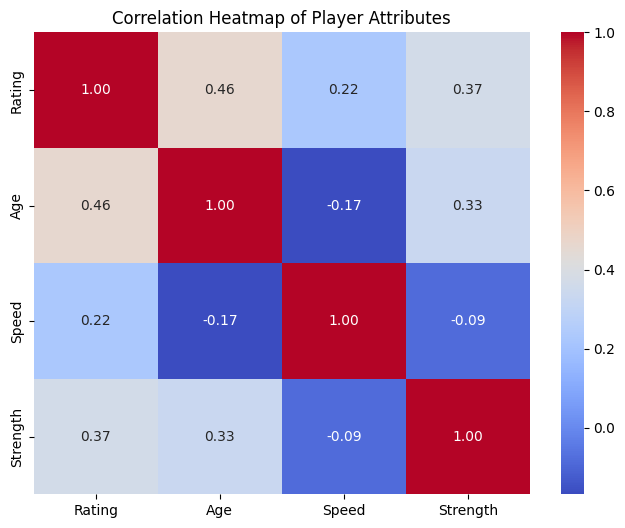

In [132]:
# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Player Attributes")
plt.show()

In [133]:
# avarage rating by age
avg_rating_by_age = (
    df.groupby('Age')['Rating']
    .mean()
    .sort_values(ascending=False)
)

avg_rating_by_age

Age
31    69.956587
32    69.867725
29    69.479167
30    69.454225
35    69.381356
36    69.295597
28    69.282243
34    69.170347
33    69.150502
37    68.970588
27    68.837743
26    68.397490
39    68.217391
40    67.812500
25    67.768326
44    67.333333
24    67.044753
38    66.500000
23    65.511062
22    64.406859
42    64.000000
41    64.000000
21    62.990803
20    60.660033
43    60.333333
19    58.572709
18    56.769231
17    55.477707
47    45.000000
Name: Rating, dtype: float64

In [134]:
# Pivot table: average rating by Age
pivot_rating_age = pd.pivot_table(
    df,
    values='Rating',
    index='Age',
    aggfunc='mean'
)

pivot_rating_age.sort_values(by='Rating', ascending=False)

,Rating
Age,
31,69.956587
32,69.867725
29,69.479167
30,69.454225
35,69.381356
36,69.295597
28,69.282243
34,69.170347
33,69.150502


In [135]:
# average rating by speed
avg_rating_by_speed = (
    df.groupby('Speed')['Rating']
    .mean()
    .sort_values(ascending=False)
)

avg_rating_by_speed

Speed
96    76.333333
95    76.000000
93    73.636364
92    72.424242
89    71.762712
        ...    
17    57.785714
24    57.666667
18    57.384615
11    57.000000
16    55.625000
Name: Rating, Length: 85, dtype: float64

In [136]:
# Pivot table: average rating by Speed
pivot_rating_speed = pd.pivot_table(
    df,
    values='Rating',
    index='Speed',
    aggfunc='mean'
)

pivot_rating_speed.sort_values(by='Rating', ascending=False)

,Rating
Speed,
96,76.333333
95,76.000000
93,73.636364
92,72.424242
89,71.762712
...,...
17,57.785714
24,57.666667
18,57.384615


In [137]:
# Analyze average rating by age
age_analysis = (
    df.groupby("Age")
      .agg(avg_rating=("Rating", "mean"))
      .reset_index()
      .sort_values("Age")
)

age_analysis.head()

,Age,avg_rating
0,17,55.477707
1,18,56.769231
2,19,58.572709
3,20,60.660033
4,21,62.990803


In [138]:
speed_rating_stats = df[["Speed", "Rating"]].describe()
speed_rating_stats

,Speed,Rating
count,17583.000000,17583.000000
mean,65.487403,66.166069
std,14.099055,7.082718
min,11.000000,45.000000
25%,58.000000,62.000000
50%,68.000000,66.000000
75%,75.000000,71.000000
max,96.000000,94.000000


### Key Insights

# Section 4

### Research Question 1: How do player physical attributes (speed and strength) change with age? (Line Plot)

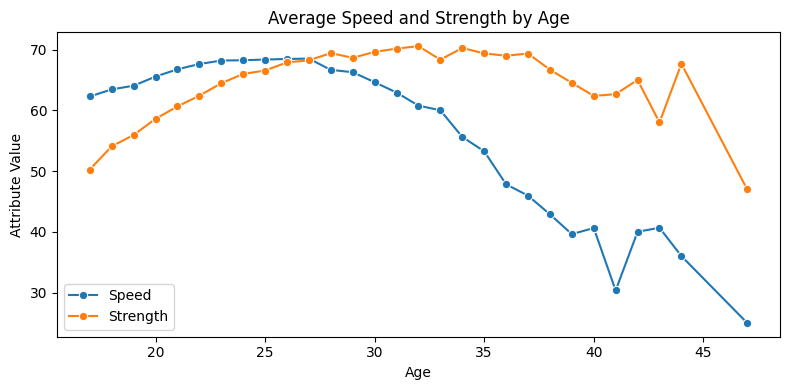

In [139]:
age_attributes = (
    df.groupby("Age")[["Speed", "Strength"]]
      .mean()
      .reset_index()
      .sort_values("Age")
)

fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(data=age_attributes, x="Age", y="Speed", label="Speed", marker="o", ax=ax)
sns.lineplot(data=age_attributes, x="Age", y="Strength", label="Strength", marker="o", ax=ax)

ax.set_title("Average Speed and Strength by Age")
ax.set_xlabel("Age")
ax.set_ylabel("Attribute Value")

fig.tight_layout()
fig.savefig("figures/attributes_vs_age.png", dpi=300)
plt.show()

Interpretation: Strength generally increases as players get older and reaches its highest levels around ages 30–35 before beginning to decrease. Speed tends to peak earlier, around age 27, and then gradually declines with age. Overall, this suggests that players reach their physical peak in their late 20s to early 30s.

### Research Question 2: Which club ositions have the highest average speed? (Bar Plot)

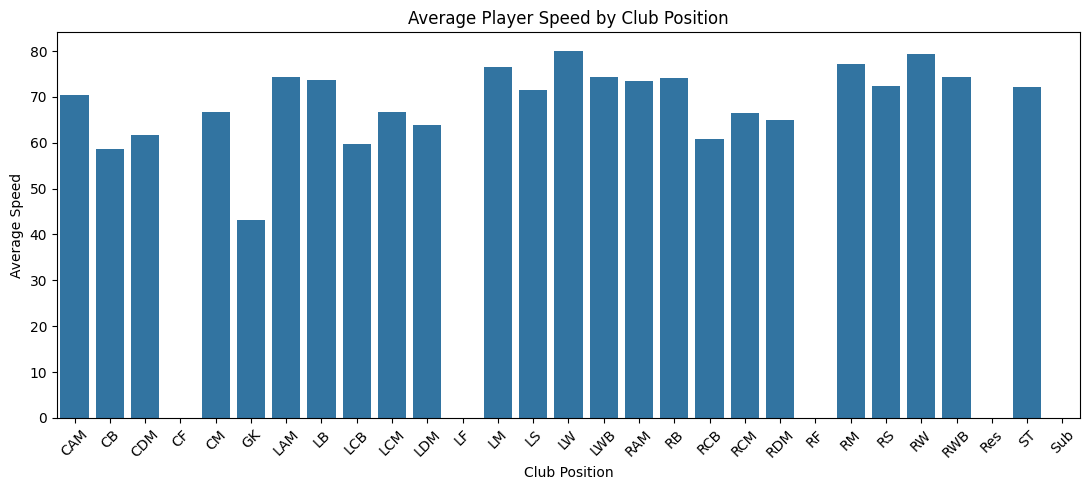

In [143]:
position_speed = (
    df.groupby("Club_Position")
      .agg(
          player_count=("Name", "count"),
          avg_speed=("Speed", "mean")
      )
      .reset_index()
)

position_speed = position_speed[
    (position_speed["Club_Position"] != "Sub") &
    (position_speed["Club_Position"] != "Res")
]
position_speed = position_speed[position_speed["player_count"] >= 20]

position_speed = position_speed.sort_values("avg_speed", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=position_speed,
    x="Club_Position",
    y="avg_speed",
    ax=ax
)

ax.set_title("Average Player Speed by Club Position")
ax.set_xlabel("Club Position")
ax.set_ylabel("Average Speed")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig("figures/speed_by_position.png", dpi=300)
plt.show()

Interpretation: Average speed is fairly similar across positions, but some positions stand out. Left Wing, Right Wing, Left Midfielder, and Right Midfielder have the highest average speeds. These positions require more running during a game, which explains why their speed is higher. Goalkeepers have the lowest average speed since they do not move around the field as much.

### Research Question 3: What is the distribution of player ratings? (Histogram)

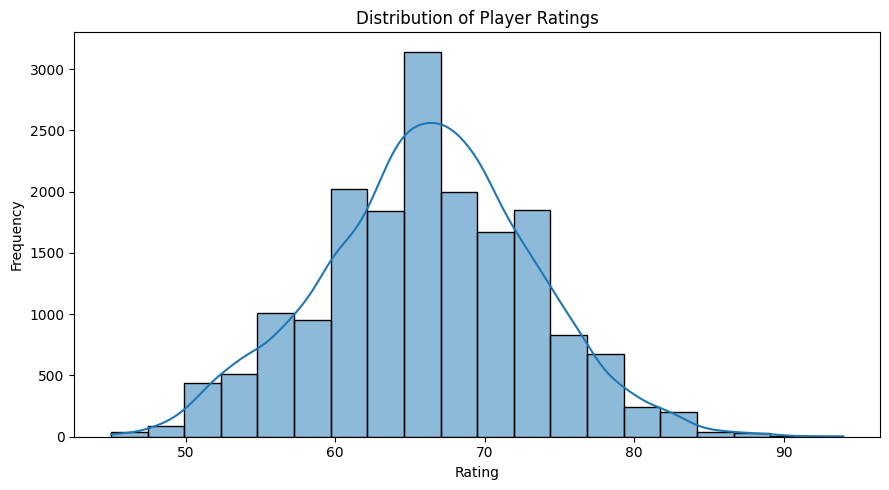

In [141]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Rating",
    bins=20,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Player Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Frequency")

fig.tight_layout()
fig.savefig("figures/rating_distribution.png", dpi=300)
plt.show()

Interpretation: Most players have mid range ratings, with fewer players having very high or very low ratings. This means the distribution is centered around average players, with only a small number of elite players.

### Research Question 4: What is the relationship between dribbling ability and ball control? (Scatter Plot)

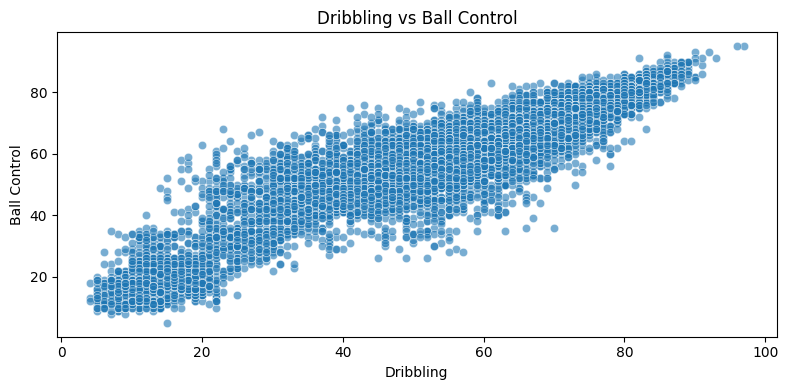

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(
    data=df,
    x="Dribbling",
    y="Ball_Control",
    alpha=0.6,
    ax=ax
)

ax.set_title("Dribbling vs Ball Control")
ax.set_xlabel("Dribbling")
ax.set_ylabel("Ball Control")

fig.tight_layout()
fig.savefig("figures/dribbling_vs_control.png", dpi=300)
plt.show()

Interpretation: There is a positive relationship between dribbling and ball controll, meaning players who can dribble well often have better ball control. However, the points are spread out, showing that dribbling alone does not determine a player’s overall ball control rating.